## Обучение моделей и отправка результата

### Импорты

In [46]:
import numpy as np
import pandas as pd
from catboost import Pool, cv, CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from IPython.display import display, Image
from src.submission.kaggle_integration import KaggleSubmitter

### Загрузка данных

In [2]:
catboost_train_20260724 = pd.read_csv('../data/catboost_train_20260724.csv')

catboost_train_df = pd.read_csv("../data/catboost_train_20260725.csv")
catboost_test_df = pd.read_csv("../data/catboost_test_20260725.csv")

encoded_train_df = pd.read_csv("../data/encoded_train_20260725.csv")
encoded_test_df = pd.read_csv("../data/encoded_test_20260725.csv")

target_col = "onshore_offshore"
id_cols = ['field_name', 'reservoir_unit']

### Подготовка обучающих множеств

In [3]:
berri_hanifa_idx = (catboost_train_df["field_name"] == "berri") & (catboost_train_df["reservoir_unit"] == "hanifa")
sabine_lake_idx = (catboost_train_df["field_name"].str.contains("sabine"))
bunyu_island_idx = (catboost_train_df["field_name"].str.contains("bunyu"))
wytch_farm_idx = (catboost_train_df["field_name"].str.contains("wytch"))
tia_juana_idx = (catboost_train_df["field_name"].str.contains("tia juana"))
cheleken_idx = (catboost_train_df["field_name"].str.contains("cheleken"))
parentis_idx = (catboost_train_df["field_name"].str.contains("parentis"))
huntington_idx = (catboost_train_df["field_name"].str.contains("huntington"))

mixed_class_fields = (wytch_farm_idx | tia_juana_idx | cheleken_idx | parentis_idx | huntington_idx)
interesting_fields = (berri_hanifa_idx | sabine_lake_idx | bunyu_island_idx)
combined_fields = (berri_hanifa_idx | sabine_lake_idx | bunyu_island_idx |
                   wytch_farm_idx | tia_juana_idx | cheleken_idx |
                   parentis_idx | huntington_idx)

mixed_class_indices = mixed_class_fields[mixed_class_fields].index.tolist()
interesting_indices = interesting_fields[interesting_fields].index.tolist()
combined_indices = combined_fields[combined_fields].index.tolist()

In [4]:
catboost_train_df[combined_fields][[*id_cols, target_col]]

,field_name,reservoir_unit,onshore_offshore
64,wytch farm,sherwood,onshore-offshore
92,tia juana,la rosa-lagunillas (tia juana onshore area),onshore-offshore
109,north sabine lake,lower hackberry (frio),onshore
134,cheleken,red series,onshore-offshore
185,parentis,unnamed,onshore-offshore
220,huntington beach,jones zone,onshore-offshore
292,berri,hanifa,offshore
298,bunyu,tarakan-santul-tabul-bunyu,onshore


In [5]:
catboost_train_df[combined_fields][[*id_cols, target_col]].equals(
    encoded_train_df[combined_fields][[*id_cols, target_col]])

True

In [6]:
cb_feature_cols = [c for c in catboost_train_df.columns if c not in [target_col, *id_cols]]
cb_X, cb_y = catboost_train_df[cb_feature_cols], catboost_train_df[target_col]
cb_le = LabelEncoder()
cb_y_encoded = cb_le.fit_transform(cb_y)
pd.concat([cb_y, pd.Series(cb_y_encoded)], axis=1).value_counts()

onshore_offshore  0
onshore           1    218
offshore          0     86
onshore-offshore  2      5
Name: count, dtype: int64

In [7]:
enc_feature_cols = [c for c in encoded_train_df.columns if c not in [target_col, *id_cols]]
enc_X, enc_y = encoded_train_df[enc_feature_cols], encoded_train_df[target_col]
enc_le = LabelEncoder()
enc_y_encoded = enc_le.fit_transform(enc_y)
pd.concat([enc_y, pd.Series(enc_y_encoded)], axis=1).value_counts()

onshore_offshore  0
onshore           1    218
offshore          0     86
onshore-offshore  2      5
Name: count, dtype: int64

In [8]:
(enc_y_encoded == cb_y_encoded).all()

np.True_

In [9]:
y_encoded = cb_y_encoded

In [10]:
split_params = dict(test_size=0.2, random_state=42, stratify=y_encoded)

In [11]:
enc_X_train, enc_X_test, enc_y_train, enc_y_test = train_test_split(enc_X, y_encoded, **split_params)
cb_X_train, cb_X_test, cb_y_train, cb_y_test = train_test_split(cb_X, y_encoded, **split_params)

In [12]:
enc_X_train.index.equals(cb_X_train.index)

True

In [13]:
catboost_train_df.loc[cb_X_train[mixed_class_fields].index, [*id_cols, target_col]]

/tmp/ipykernel_1847599/3979259546.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  catboost_train_df.loc[cb_X_train[mixed_class_fields].index, [*id_cols, target_col]]


,field_name,reservoir_unit,onshore_offshore
64,wytch farm,sherwood,onshore-offshore
92,tia juana,la rosa-lagunillas (tia juana onshore area),onshore-offshore
185,parentis,unnamed,onshore-offshore
134,cheleken,red series,onshore-offshore


In [14]:
catboost_train_df.loc[cb_X_test[mixed_class_fields].index, [*id_cols, target_col]]

/tmp/ipykernel_1847599/2827046411.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  catboost_train_df.loc[cb_X_test[mixed_class_fields].index, [*id_cols, target_col]]


,field_name,reservoir_unit,onshore_offshore
220,huntington beach,jones zone,onshore-offshore


Только Huntington Beach отнесён к тестовой выборке, а все остальные - к обучающей.

### Decision Tree + Random Forest

In [15]:
dt_params = dict(max_depth=3, min_samples_split=5, min_samples_leaf=3, random_state=42)
rf_params = dict(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
dt = DecisionTreeClassifier(**dt_params)
rf = RandomForestClassifier(**rf_params)
cv_dt_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_scores = cross_val_score(rf, enc_X, enc_y_encoded, cv=cv_dt_rf, scoring="neg_log_loss")
dt_scores = cross_val_score(dt, enc_X, enc_y_encoded, cv=cv_dt_rf, scoring="neg_log_loss")
print(f"Random Forest: средняя LogLoss-мера на кросс-валидации: {-rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
print(f"Decision Tree: средняя LogLoss-мера на кросс-валидации: {-dt_scores.mean():.4f} (+/- {dt_scores.std():.4f})")

Random Forest: средняя LogLoss-мера на кросс-валидации: 0.1160 (+/- 0.0072)
Decision Tree: средняя LogLoss-мера на кросс-валидации: 0.6196 (+/- 0.5049)


In [16]:
random_forest = RandomForestClassifier(**rf_params)
random_forest.fit(enc_X_train, enc_y_train)
random_forest_enc_y_pred = random_forest.predict(enc_X_test)
random_forest_micro = f1_score(enc_y_test, random_forest_enc_y_pred, average='micro')
random_forest_macro = f1_score(enc_y_test, random_forest_enc_y_pred, average='macro')
print(f"Random Forest: F1-мера (micro) на разделении train/test: {random_forest_micro:.15f}")
print(f"Random Forest: F1-мера (macro) на разделении train/test: {random_forest_macro:.15f}")

Random Forest: F1-мера (micro) на разделении train/test: 0.983870967741935
Random Forest: F1-мера (macro) на разделении train/test: 0.662921348314607


In [17]:
decision_tree = DecisionTreeClassifier(**dt_params)
decision_tree.fit(enc_X_train, enc_y_train)
decision_tree_y_pred = decision_tree.predict(enc_X_test)
decision_tree_micro = f1_score(enc_y_test, decision_tree_y_pred, average='micro')
decision_tree_macro = f1_score(enc_y_test, decision_tree_y_pred, average='macro')
print(f"Decision Tree: F1-мера (micro) на разделении train/test: {decision_tree_micro:.15f}")
print(f"Decision Tree: F1-мера (macro) на разделении train/test: {decision_tree_macro:.15f}")

Decision Tree: F1-мера (micro) на разделении train/test: 0.983870967741935
Decision Tree: F1-мера (macro) на разделении train/test: 0.662921348314607


### Catboost

In [18]:
cat_cols = cb_X.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
cb_X[cat_cols] = cb_X[cat_cols].astype('category')

In [19]:
pool = Pool(cb_X, cb_y_encoded, cat_features=cat_cols)

In [20]:
cb_params = {'loss_function': 'MultiClass', 'iterations': 150, 'verbose': False}
cb_params_micro = {**cb_params, 'eval_metric': 'TotalF1:average=Micro'}
cb_params_macro = {**cb_params, 'eval_metric': 'TotalF1:average=Macro'}
cv_settings = {'pool': pool, 'fold_count': 5, 'stratified': True, 'partition_random_seed': 42, "as_pandas": True}

cv_micro_results = cv(**cv_settings, params=cb_params_micro)
cv_macro_results = cv(**cv_settings, params=cb_params_macro)

Training on fold [0/5]

bestTest = 0.9841269841
bestIteration = 0

Training on fold [1/5]

bestTest = 0.9838709677
bestIteration = 0

Training on fold [2/5]

bestTest = 0.9838709677
bestIteration = 0

Training on fold [3/5]

bestTest = 0.9672131148
bestIteration = 2

Training on fold [4/5]

bestTest = 0.9836065574
bestIteration = 1

Training on fold [0/5]

bestTest = 0.6629213483
bestIteration = 0

Training on fold [1/5]

bestTest = 0.6629213483
bestIteration = 0

Training on fold [2/5]

bestTest = 0.6629213483
bestIteration = 0

Training on fold [3/5]

bestTest = 0.6493909192
bestIteration = 5

Training on fold [4/5]

bestTest = 0.662835249
bestIteration = 1


In [21]:
best_catboost_micro = cv_micro_results['test-TotalF1:average=Micro-mean'].max()
best_catboost_macro = cv_macro_results['test-TotalF1:average=Macro-mean'].max()
print(f"Catboost: лучшее значение F1-меры (micro): {best_catboost_micro:.15f}")
print(f"Catboost: лучшее значение F1-меры (macro): {best_catboost_macro:.15f}")

Catboost: лучшее значение F1-меры (micro): 0.980537718348401
Catboost: лучшее значение F1-меры (macro): 0.660198042628865


In [22]:
train_pool = Pool(cb_X_train, cb_y_train, cat_features=cat_cols)
eval_pool = Pool(cb_X_test, cb_y_test, cat_features=cat_cols)

In [23]:
cb_model_micro = CatBoostClassifier(**cb_params_micro)
cb_model_macro = CatBoostClassifier(**cb_params_macro)

cb_model_micro.fit(train_pool, eval_set=eval_pool, early_stopping_rounds=50)
cb_model_macro.fit(train_pool, eval_set=eval_pool, early_stopping_rounds=50)

CatBoostClassifier(eval_metric='TotalF1:average=Macro', iterations=150, loss_function='MultiClass', verbose=False)

In [24]:
cb_eval_micro = max(cb_model_micro.get_evals_result()['validation']['TotalF1:average=Micro'])
cb_eval_macro = max(cb_model_macro.get_evals_result()['validation']['TotalF1:average=Macro'])
print(f"Catboost: лучшее значение F1-меры (micro): {cb_eval_micro:.15f}")
print(f"Catboost: лучшее значение F1-меры (macro): {cb_eval_macro:.15f}")

Catboost: лучшее значение F1-меры (micro): 0.983870967741935
Catboost: лучшее значение F1-меры (macro): 0.662921348314607


### Сравнение и выбор моделей

In [25]:
pd.DataFrame([
    {"model": "Random Forest", "F1 Micro": random_forest_micro, "F1 Macro": random_forest_macro},
    {"model": "Decision Tree", "F1 Micro": decision_tree_micro, "F1 Macro": decision_tree_macro},
    {"model": "Catboost", "F1 Micro": cb_eval_micro, "F1 Macro": cb_eval_macro},
]).sort_values(["F1 Micro", "F1 Macro"], ascending=[False, False])

,model,F1 Micro,F1 Macro
0,Random Forest,0.983871,0.662921
1,Decision Tree,0.983871,0.662921
2,Catboost,0.983871,0.662921


Все модели показывают идентичные скоры. 

#### Как модели ошибаются?
Посмотрим, как модели ошибаются.

In [26]:
cb_micro_preds = cb_model_micro.predict(cb_X)
cb_macro_preds = cb_model_macro.predict(cb_X)
rf_preds = random_forest.predict(enc_X)
dt_preds = decision_tree.predict(enc_X)

cb_micro_errors = np.where(cb_micro_preds.flatten() != cb_y_encoded)[0]
cb_macro_errors = np.where(cb_macro_preds.flatten() != cb_y_encoded)[0]
rf_errors = np.where(rf_preds.flatten() != enc_y_encoded)[0]
dt_errors = np.where(dt_preds.flatten() != enc_y_encoded)[0]

In [27]:
def check_mispredictions(error_idx, preds):
    eval_df = catboost_train_df.loc[error_idx, [*id_cols, target_col]]
    eval_df['predicted'] = cb_le.inverse_transform(preds[error_idx].flatten())
    return eval_df

In [28]:
micro_mispredictions = check_mispredictions(cb_micro_errors, cb_micro_preds)
macro_mispredictions = check_mispredictions(cb_macro_errors, cb_macro_preds)
assert micro_mispredictions.equals(macro_mispredictions)
micro_mispredictions

,field_name,reservoir_unit,onshore_offshore,predicted
64,wytch farm,sherwood,onshore-offshore,onshore
92,tia juana,la rosa-lagunillas (tia juana onshore area),onshore-offshore,onshore
109,north sabine lake,lower hackberry (frio),onshore,offshore
134,cheleken,red series,onshore-offshore,offshore
185,parentis,unnamed,onshore-offshore,onshore
220,huntington beach,jones zone,onshore-offshore,onshore
298,bunyu,tarakan-santul-tabul-bunyu,onshore,offshore


Большинство ошибок Catboost в смешанных классах.

In [29]:
check_mispredictions(dt_errors, dt_preds)

,field_name,reservoir_unit,onshore_offshore,predicted
34,villeperdue,dalle nacree,onshore,onshore-offshore
92,tia juana,la rosa-lagunillas (tia juana onshore area),onshore-offshore,onshore
134,cheleken,red series,onshore-offshore,offshore
220,huntington beach,jones zone,onshore-offshore,onshore
298,bunyu,tarakan-santul-tabul-bunyu,onshore,offshore


Decision Tree не справляется со смешанными классами. DT не распознало месторождение не берегу Маракайбо, хотя оно было в обучающей выборке. Сложными оказались остров Bunyu, Huntington Beach и Cheleken.

По-видимому, не хватает признаков и наблюдений.

In [30]:
check_mispredictions(rf_errors, rf_preds)

,field_name,reservoir_unit,onshore_offshore,predicted
220,huntington beach,jones zone,onshore-offshore,onshore


Random Forest не справился только с Huntington Beach. Продолжим с Random Forest.

### Оптимизация гиперпараметров
Сфокусируемся на оптимизации гиперпараметров модели на основе Random Forest с упором на F1 Macro, чтобы попытаться улучшить качество в части классов, для которых мало наблюдений.

In [31]:
param_grid = {
    'n_estimators': [50, 150, 200],
    'max_depth': [2, 3, 4, 5, 7, 10, None],
    'min_samples_split': [2, 3, 5],
    'criterion': ['entropy', 'gini'],
    'random_state': [42]
}

rf = RandomForestClassifier()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average='macro')

grid = GridSearchCV(rf, param_grid, cv=cv, scoring=scorer, n_jobs=-1)
grid.fit(enc_X, enc_y_encoded)

print(f"F1-мера (macro) для лучшего набора параметров: {grid.best_score_:.4f}")
print(f"Лучший набор параметров: {grid.best_params_}")

F1-мера (macro) для лучшего набора параметров: 0.6617
Лучший набор параметров: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 150, 'random_state': 42}


In [32]:
best_random_forest = RandomForestClassifier(**grid.best_params_)
best_random_forest.fit(enc_X_train, enc_y_train)
best_random_forest_enc_y_pred = best_random_forest.predict(enc_X_test)
best_random_forest_macro = f1_score(enc_y_test, best_random_forest_enc_y_pred, average='macro')
print(
    f"Random Forest с лучшим набором параметров: F1-мера (macro) на разделении train/test: {best_random_forest_macro:.15f}")

Random Forest с лучшим набором параметров: F1-мера (macro) на разделении train/test: 0.662921348314607


In [33]:
best_rf_preds = best_random_forest.predict(enc_X)
best_rf_errors = np.where(best_rf_preds.flatten() != enc_y_encoded)[0]
check_mispredictions(best_rf_errors, best_rf_preds)

,field_name,reservoir_unit,onshore_offshore,predicted
64,wytch farm,sherwood,onshore-offshore,onshore
92,tia juana,la rosa-lagunillas (tia juana onshore area),onshore-offshore,onshore
97,dzhigalybeg,red series,offshore,onshore
134,cheleken,red series,onshore-offshore,onshore
185,parentis,unnamed,onshore-offshore,onshore
220,huntington beach,jones zone,onshore-offshore,onshore


Как видно, перебор гиперпараметров не помог улучшить ситуацию.

### Отправка предсказания на соревнование

In [34]:
enc_feature_cols_test = [c for c in encoded_test_df.columns if c not in [target_col, *id_cols]]

In [35]:
test_X = encoded_test_df[enc_feature_cols_test]

In [36]:
random_forest_enc_y_pred = random_forest.predict(test_X)

In [40]:
submission_df = (pd.DataFrame(random_forest_enc_y_pred, columns=["Onshore/Offshore"]).reset_index())

In [41]:
submission_df['Onshore/Offshore'].value_counts()

Onshore/Offshore
1    97
0    36
Name: count, dtype: int64

In [ ]:
submission_df.to_csv("../data/submission_1.csv", index=False)

In [42]:
submitter = KaggleSubmitter(competition="classification-of-oil-and-gas")
submitter.auth()

In [44]:
submission_hash = "Submission 1: Random Forest ('n_estimators': 100, 'max_depth': 10, 'random_state': 42)"
submitter.submit_entry(submission_hash=submission_hash, submission_path="../data/submission_1.csv")

100%|██████████| 711/711 [00:00<00:00, 1.24kB/s]


In [ ]:
attrs = ["date", "description", "publicScore", "ref"]

In [45]:
submission_result = submitter.get_submission_by_hash(submission_hash)
print(f"ref: {submission_result.ref}")
print(f"date: {submission_result.date}")
print(f"description: {submission_result.description}")
print(f"publicScore: {submission_result.public_score}")

ref: 54984521
date: 2026-07-25 20:52:13.680000
description: Submission 1: Random Forest ('n_estimators': 100, 'max_depth': 10, 'random_state': 42)
publicScore: 0.94916


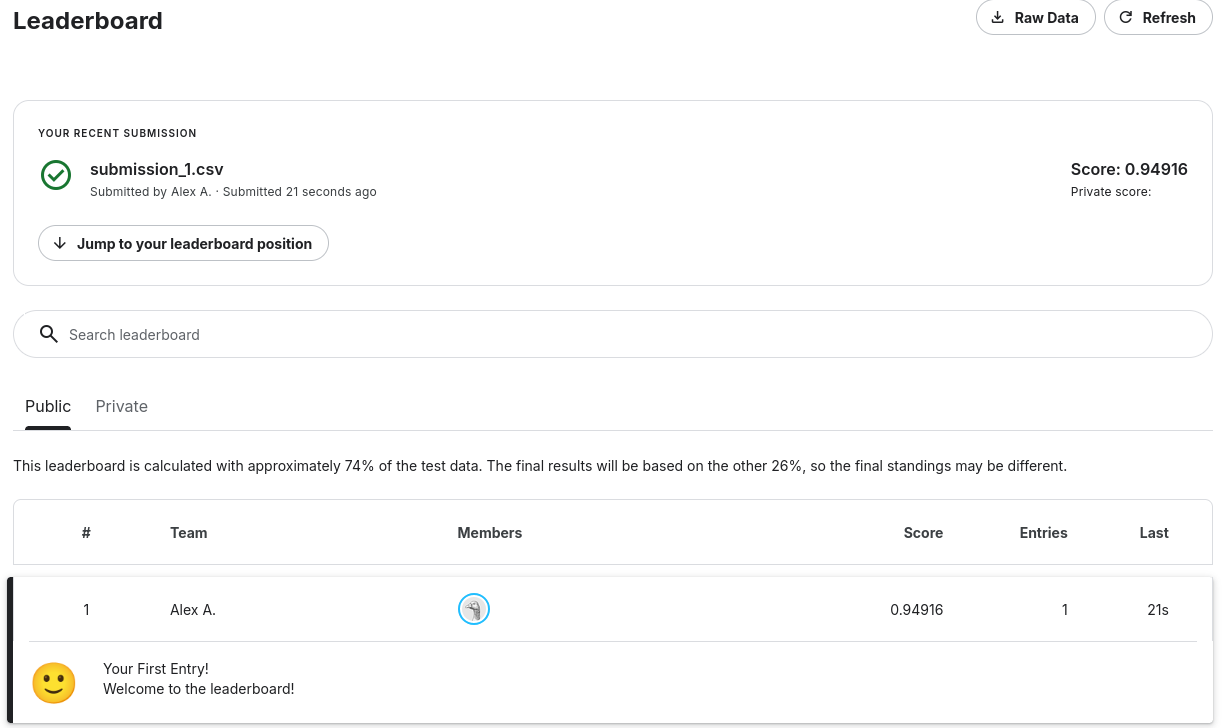

In [47]:
display(Image("../doc/img/submission_screenshot.png", width=500))

Submission 1 набрал publicScore=0.94916. Вероятно, в датасете были смешанные классы. 

Улучшить результат можно построив дополнительные признаки на основании признака TVD и справочника с бариметрическими данными для координат (GEBCO).